In [19]:
#adding libraries
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
!pip install umap-learn
import umap


   -------------------- ------------------- 1/2 [umap-learn]
   ---------------------------------------- 2/2 [umap-learn]




[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
#data import
train = pd.read_csv('C:/Users/yezav/OneDrive/Desktop/BABSON/Machine Learning/StumbleUpon/train.tsv', sep='\t', na_values=['?'])
test  = pd.read_csv('C:/Users/yezav/OneDrive/Desktop/BABSON/Machine Learning/StumbleUpon/test.tsv',  sep='\t', na_values=['?'])

print(train.shape, test.shape)   # (7395, 27), (3171, 26)


(7395, 27) (3171, 26)


In [21]:
# adding words into themes based on frequency
# Keyword themes. Built from category-conditioned log-ratio analysis
COOKING_WORDS = {
    'cup', 'cups', 'tsp', 'tbsp', 'teaspoon', 'tablespoon', 'tablespoons',
    'oz', 'ounces', 'grams',
    'flour', 'sugar', 'salt', 'pepper', 'butter', 'oil',
    'bake', 'baking', 'boil', 'boiling', 'fry', 'frying', 'roast', 'grill',
    'mix', 'mixture', 'whisk', 'stir', 'chop', 'chopped', 'slice', 'sliced',
    'minced', 'drain', 'garnish', 'softened', 'caramelized',
    'recipe', 'recipes', 'dough', 'sauce', 'pastry', 'filling', 'frosting',
    'oven', 'pan', 'skillet', 'pot', 'foil', 'sheet', 'springform',
    'cheese', 'cheddar', 'cream', 'milk', 'buttermilk', 'yeast',
    'chicken', 'beef', 'steak', 'bacon', 'salmon', 'shrimp', 'sushi', 'stew',
    'onion', 'garlic', 'tomato', 'potato', 'potatoes', 'celery', 'basil',
    'zucchini', 'pumpkin', 'chickpeas', 'beans', 'mashed',
    'pasta', 'lasagna', 'pizza', 'bread', 'biscuits', 'pancakes', 'tortillas',
    'cookie', 'cookies', 'cake', 'cheesecake', 'pudding', 'fudge', 'caramel',
    'chocolate', 'nutella', 'peanut', 'cinnamon', 'syrup', 'meringue', 'ganache',
    'butterscotch', 'blueberry',
    'crispy', 'chewy', 'crunchy', 'creamy', 'spicy', 'tart',
    'smoothie', 'smoothies',
    'serving', 'servings', 'marinade', 'boneless',
}

FITNESS_WORDS = {
    'fitness', 'workout', 'workouts', 'exercise', 'exercises',
    'gym', 'walking', 'running', 'cardio', 'strength',
    'muscles', 'muscle', 'resistance', 'belt',
    'diet', 'nutrition', 'healthy', 'natural',
    'massage', 'tension', 'yoga', 'stretching',
}

TECH_NEWS_WORDS = {
    'iphone', 'samsung', 'android', 'smartphone', 'mobile', 'pc', 'desktop',
    'chrome', 'usb', 'qr', 'app', 'apps', 'tech',
    'malware', 'security', 'password', 'patent',
    'data', 'device', 'devices', 'printer', 'maps',
    'innovation', 'innovative', 'powered',
}

CELEBRITY_WORDS = {
    'celebrity', 'celebrities', 'fans', 'dating',
    'simpson', 'nicole', 'michelle', 'miller', 'jones',
    'dior', 'vintage', 'navy', 'urban',
    'dresses', 'shoes', 'jeans', 'clothing', 'clothes',
    'boots', 'swimsuit', 'designers',
    'films', 'fox',
}

SPORTS_NEWS_WORDS = {
    'cbssports', 'nfl', 'yankees', 'ravens', 'jersey',
    'cheerleaders', 'passing', 'signed', 'player',
    'fans', 'record', 'million', 'billion',
}

HTML_NOISE_WORDS = {
    'jpg', 'png', 'gif', 'href', 'www', 'http', 'https',
    'image', 'img', 'link', 'links',
}

THEMES = {
    'n_cooking_words': COOKING_WORDS,
    'n_fitness_words': FITNESS_WORDS,
    'n_tech_news_words': TECH_NEWS_WORDS,
    'n_celebrity_words': CELEBRITY_WORDS,
    'n_sports_news_words': SPORTS_NEWS_WORDS,
    'n_html_noise_words': HTML_NOISE_WORDS,
}

print(f"Themes: {list(THEMES.keys())}")
print(f"Total keywords across all themes: {sum(len(v) for v in THEMES.values())}")


Themes: ['n_cooking_words', 'n_fitness_words', 'n_tech_news_words', 'n_celebrity_words', 'n_sports_news_words', 'n_html_noise_words']
Total keywords across all themes: 206


In [22]:
# Cleaning: same transformations applied to train and test 

def parse_boilerplate(df):
    """Parse the boilerplate JSON column into bp_title, bp_body, bp_url."""
    def safe_parse(x):
        try:
            return json.loads(x) if isinstance(x, str) else {}
        except (json.JSONDecodeError, TypeError):
            return {}
    parsed = df['boilerplate'].apply(safe_parse)
    df['bp_title'] = parsed.apply(lambda d: d.get('title') or '')
    df['bp_body']  = parsed.apply(lambda d: d.get('body')  or '')
    df['bp_url']   = parsed.apply(lambda d: d.get('url')   or '')
    return df

train = parse_boilerplate(train)
test  = parse_boilerplate(test)

# Flag pages where both title and body are empty (scrape failure)
train['both_empty'] = ((train['bp_title'] == '') & (train['bp_body'] == '')).astype(int)
test['both_empty']  = ((test['bp_title']  == '') & (test['bp_body']  == '')).astype(int)

# alchemy_category: '?' means missing → fill with 'unknown' string
# alchemy_category_score: '?' means missing → flag + fill with -1 sentinel
for df in (train, test):
    df['alchemy_category'] = df['alchemy_category'].replace('?', 'unknown').fillna('unknown')
    df['alchemy_score_missing'] = (df['alchemy_category_score'] == '?').astype(int)
    df['alchemy_category_score'] = pd.to_numeric(
        df['alchemy_category_score'].replace('?', np.nan), errors='coerce'
    ).fillna(-1)

# is_news, news_front_page: NaN means "not news" → fill with 0
for col in ['is_news', 'news_front_page']:
    train[col] = pd.to_numeric(train[col], errors='coerce').fillna(0).astype(int)
    test[col]  = pd.to_numeric(test[col],  errors='coerce').fillna(0).astype(int)

# Drop framebased: constant column (only value 0), zero variance
if 'framebased' in train.columns:
    train = train.drop(columns=['framebased'])
    test = test.drop(columns=['framebased'])

# Verify
print(f"\nCleaned train: {train.shape}, test: {test.shape}")
print(f"\nNaN counts (train):")
print(train.isna().sum()[train.isna().sum() > 0])
print(f"\nNaN counts (test):")
print(test.isna().sum()[test.isna().sum() > 0])


Cleaned train: (7395, 31), test: (3171, 30)

NaN counts (train):
Series([], dtype: int64)

NaN counts (test):
Series([], dtype: int64)


In [23]:
# Build theme count features on train and test 
# For each row, count how many words from each theme appear in (bp_title + bp_body).
# Lowercase + simple split on whitespace
# Build theme count features on train and test

import re

def tokenize(text):
    """Lowercase, strip non-letter chars, split on whitespace. Returns a set for O(1) lookup."""
    text = (text or '').lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return set(text.split())

def add_theme_features(df, themes):
    """Add one count column per theme to df."""
    combined = (df['bp_title'].fillna('') + ' ' + df['bp_body'].fillna('')).apply(tokenize)
    for col_name, keyword_set in themes.items():
        df[col_name] = combined.apply(lambda tokens: len(tokens & keyword_set))
    return df

train = add_theme_features(train, THEMES)
test  = add_theme_features(test,  THEMES)

# Sanity check: ratio of mean theme count between classes
theme_cols = list(THEMES.keys())
means = train.groupby('label')[theme_cols].mean()

summary = pd.DataFrame({
    'ephemeral_mean': means.loc[0].round(2),
    'evergreen_mean': means.loc[1].round(2),
})
summary['ratio'] = (summary[['ephemeral_mean', 'evergreen_mean']].max(axis=1) /
                    summary[['ephemeral_mean', 'evergreen_mean']].min(axis=1)).round(2)
summary['favors'] = summary.apply(
    lambda r: 'evergreen' if r['evergreen_mean'] > r['ephemeral_mean'] else 'ephemeral', axis=1
)
print(summary.sort_values('ratio', ascending=False))

                     ephemeral_mean  evergreen_mean  ratio     favors
n_cooking_words                1.25           10.61   8.49  evergreen
n_tech_news_words              0.47            0.10   4.70  ephemeral
n_sports_news_words            0.27            0.07   3.86  ephemeral
n_celebrity_words              0.41            0.13   3.15  ephemeral
n_html_noise_words             0.31            0.19   1.63  ephemeral
n_fitness_words                0.44            0.65   1.48  evergreen


In [24]:
# Drop weak theme features (fitness, html_noise. They have only ~1.5x relative gap)
weak_themes = ['n_fitness_words', 'n_html_noise_words']
train = train.drop(columns=weak_themes, errors='ignore')
test  = test.drop(columns=weak_themes, errors='ignore')
for k in weak_themes:
    THEMES.pop(k, None)

print(f"Remaining themes: {list(THEMES.keys())}")
print(f"train shape: {train.shape}, test shape: {test.shape}")

Remaining themes: ['n_cooking_words', 'n_tech_news_words', 'n_celebrity_words', 'n_sports_news_words']
train shape: (7395, 35), test shape: (3171, 34)


In [25]:
#Model 1: Logistic Regression on TF-IDF + structured features *******************

# Build feature matrices for LR
# TF-IDF of bp_title + bp_body  +  structured numeric/categorical features

from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler

# Combine title + body into one text field
train['text'] = train['bp_title'].fillna('') + ' ' + train['bp_body'].fillna('')
test['text']  = test['bp_title'].fillna('')  + ' ' + test['bp_body'].fillna('')

# TF-IDF: fit on train only, then transform both
tfidf = TfidfVectorizer(
    min_df=3,           # ignore words appearing in fewer than 3 docs
    max_df=0.9,         # ignore words appearing in >90% of docs
    ngram_range=(1, 2), # unigrams + bigrams
    sublinear_tf=True,  # log-scale term frequency
    strip_accents='unicode',
    stop_words='english',
)
X_text_train = tfidf.fit_transform(train['text'])
X_text_test  = tfidf.transform(test['text'])
print(f"TF-IDF matrix: train {X_text_train.shape}, test {X_text_test.shape}")

# Structured features: numeric columns + theme counts
# Drop non-feature columns (text, ids, raw boilerplate, etc.)
drop_cols = ['url', 'urlid', 'boilerplate', 'bp_title', 'bp_body', 'bp_url', 'text', 'label']
struct_cols = [c for c in train.columns if c not in drop_cols]

# alchemy_category is the only string column — one-hot encode it
struct_train = pd.get_dummies(train[struct_cols], columns=['alchemy_category'], drop_first=False)
struct_test  = pd.get_dummies(test[struct_cols],  columns=['alchemy_category'], drop_first=False)

# Align columns (in case test is missing a category that train has, or vice versa)
struct_train, struct_test = struct_train.align(struct_test, join='left', axis=1, fill_value=0)    #not so sure

# Cast everything to float for the scaler
struct_train = struct_train.astype(float)
struct_test  = struct_test.astype(float)

# Standardize structured features (LR is sensitive to feature scale)
scaler = StandardScaler()
X_struct_train = scaler.fit_transform(struct_train)
X_struct_test  = scaler.transform(struct_test)
print(f"Structured matrix: train {X_struct_train.shape}, test {X_struct_test.shape}")

# Stack TF-IDF (sparse) + structured (dense) horizontally into one big sparse matrix
X_train_lr = hstack([X_text_train, csr_matrix(X_struct_train)]).tocsr()
X_test_lr  = hstack([X_text_test,  csr_matrix(X_struct_test)]).tocsr()
y = train['label'].values

print(f"\nFinal Logistic Regression matrix: train {X_train_lr.shape}, test {X_test_lr.shape}")

TF-IDF matrix: train (7395, 97147), test (3171, 97147)
Structured matrix: train (7395, 40), test (3171, 40)

Final Logistic Regression matrix: train (7395, 97187), test (3171, 97187)


In [26]:
# Cross-validate Logistic Regression — 5-fold AUC

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

logistic_regression = LogisticRegression(C=1.0, solver='liblinear', max_iter=1000)

scores = cross_val_score(logistic_regression, X_train_lr, y, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"Logistic Regression Cross-Validation Area Under the Curve per fold: {scores.round(4)}")
print(f"Logistic Regression mean Area Under the Curve: {scores.mean():.4f}  ± {scores.std():.4f}")

Logistic Regression Cross-Validation Area Under the Curve per fold: [0.8633 0.8764 0.8602 0.8553 0.8664]
Logistic Regression mean Area Under the Curve: 0.8643  ± 0.0071


In [27]:
# Logistic Regression interpretation: top words/features driving each class

logistic_regression_full = LogisticRegression(C=1.0, solver='liblinear', max_iter=1000)
logistic_regression_full.fit(X_train_lr, y)

# Build full feature name list: TF-IDF vocabulary + structured columns
tfidf_feature_names = tfidf.get_feature_names_out()
structured_feature_names = struct_train.columns.tolist()
all_feature_names = list(tfidf_feature_names) + structured_feature_names

coefficients = logistic_regression_full.coef_[0]

# Top 25 evergreen-pushing features (most positive coefficients)
top_evergreen_idx = np.argsort(coefficients)[::-1][:25]
print("Top 25 EVERGREEN features (Logistic Regression):")
for i in top_evergreen_idx:
    print(f"  {all_feature_names[i]:30s}  coefficient={coefficients[i]:+.3f}")

# Top 25 ephemeral-pushing features (most negative coefficients)
top_ephemeral_idx = np.argsort(coefficients)[:25]
print("\nTop 25 EPHEMERAL features (Logistic Regression):")
for i in top_ephemeral_idx:
    print(f"  {all_feature_names[i]:30s}  coefficient={coefficients[i]:+.3f}")

Top 25 EVERGREEN features (Logistic Regression):
  recipe                          coefficient=+3.245
  recipes                         coefficient=+2.804
  make                            coefficient=+2.203
  food                            coefficient=+2.065
  recipe allrecipes               coefficient=+1.504
  allrecipes com                  coefficient=+1.483
  allrecipes                      coefficient=+1.437
  cheese                          coefficient=+1.263
  cook                            coefficient=+1.237
  easy                            coefficient=+1.221
  cooking                         coefficient=+1.205
  tea                             coefficient=+1.159
  cake                            coefficient=+1.158
  body                            coefficient=+1.083
  perfect                         coefficient=+1.048
  healthy                         coefficient=+1.028
  ways                            coefficient=+1.013
  nutella                         coefficient=+0.9

In [28]:
# Model 2: Classification Tree **********************************

# Build feature matrix for Classification Tree
# give the tree the structured features (numeric, flags, one-hot category, theme counts) — about 40 columns  #review????
# of dense, meaningful features that match how trees actually work.

# Reusing the structured matrix we already built for Logistic Regression
X_train_tree = struct_train.values
X_test_tree  = struct_test.values

print(f"Tree matrix: train {X_train_tree.shape}, test {X_test_tree.shape}")
print(f"Feature names: {list(struct_train.columns)}")

Tree matrix: train (7395, 40), test (3171, 40)
Feature names: ['alchemy_category_score', 'avglinksize', 'commonlinkratio_1', 'commonlinkratio_2', 'commonlinkratio_3', 'commonlinkratio_4', 'compression_ratio', 'embed_ratio', 'frameTagRatio', 'hasDomainLink', 'html_ratio', 'image_ratio', 'is_news', 'lengthyLinkDomain', 'linkwordscore', 'news_front_page', 'non_markup_alphanum_characters', 'numberOfLinks', 'numwords_in_url', 'parametrizedLinkRatio', 'spelling_errors_ratio', 'both_empty', 'alchemy_score_missing', 'n_cooking_words', 'n_tech_news_words', 'n_celebrity_words', 'n_sports_news_words', 'alchemy_category_arts_entertainment', 'alchemy_category_business', 'alchemy_category_computer_internet', 'alchemy_category_culture_politics', 'alchemy_category_gaming', 'alchemy_category_health', 'alchemy_category_law_crime', 'alchemy_category_recreation', 'alchemy_category_religion', 'alchemy_category_science_technology', 'alchemy_category_sports', 'alchemy_category_unknown', 'alchemy_category_wea

In [29]:
# Cross-validate Classification Tree — 5-fold Area Under the Curve

from sklearn.tree import DecisionTreeClassifier

classification_tree = DecisionTreeClassifier(
    max_depth=8,           # cap depth to prevent overfitting
    min_samples_leaf=20,   # each leaf needs at least 20 samples (smooths predictions)
    random_state=42,
)

scores_tree = cross_val_score(
    classification_tree, X_train_tree, y,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
)
print(f"Classification Tree Cross-Validation AUC per fold: {scores_tree.round(4)}")
print(f"Classification Tree mean AUC: {scores_tree.mean():.4f}  ± {scores_tree.std():.4f}")

Classification Tree Cross-Validation AUC per fold: [0.8161 0.8249 0.8191 0.8241 0.8223]
Classification Tree mean AUC: 0.8213  ± 0.0033


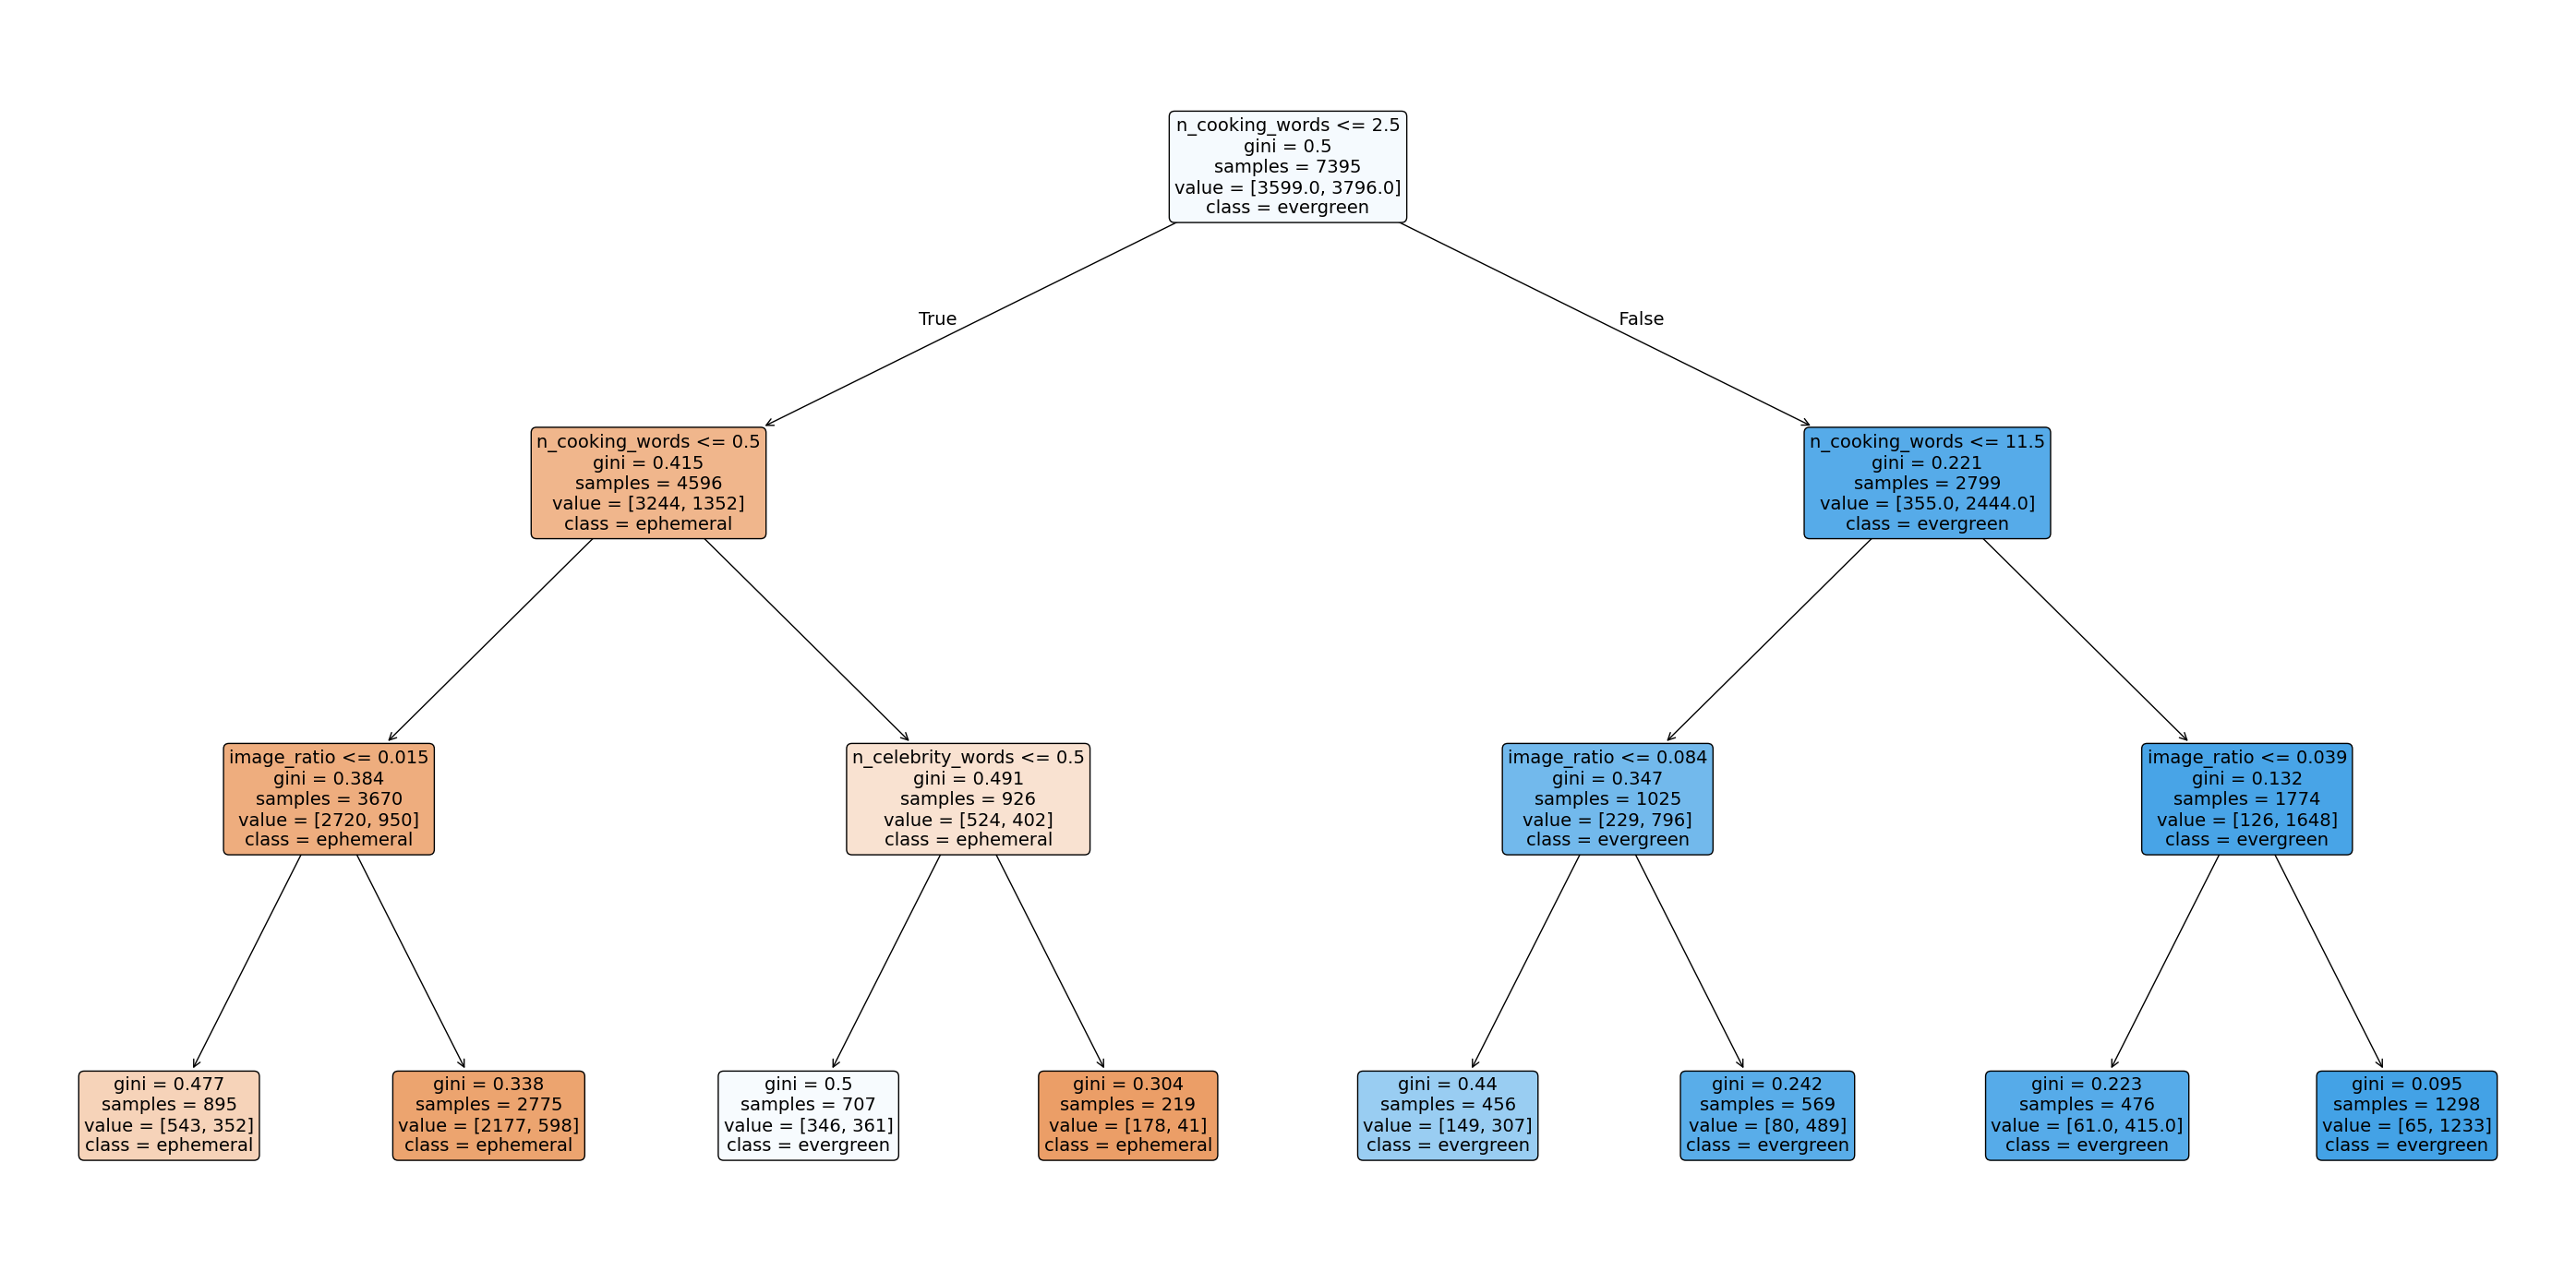

In [30]:
# Classification Tree visualization (depth 3 for readability)
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree_for_plot = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=20,
    random_state=42,
)
tree_for_plot.fit(X_train_tree, y)

plt.figure(figsize=(28, 14))
plot_tree(
    tree_for_plot,
    feature_names=struct_train.columns.tolist(),
    class_names=['ephemeral', 'evergreen'],
    filled=True,
    rounded=True,
    fontsize=14,
)
plt.tight_layout()
plt.show()


In [31]:
# Tree feature importance 
importances = pd.Series(
    tree_for_plot.feature_importances_,
    index=struct_train.columns,
).sort_values(ascending=False)

print("Classification Tree feature importance (top 15):")
print(importances.head(15).round(4))

Classification Tree feature importance (top 15):
n_cooking_words           0.9258
image_ratio               0.0481
n_celebrity_words         0.0261
alchemy_category_score    0.0000
commonlinkratio_3         0.0000
avglinksize               0.0000
commonlinkratio_1         0.0000
commonlinkratio_2         0.0000
embed_ratio               0.0000
compression_ratio         0.0000
commonlinkratio_4         0.0000
hasDomainLink             0.0000
is_news                   0.0000
lengthyLinkDomain         0.0000
linkwordscore             0.0000
dtype: float64


In [32]:
#k-nearest neighbors on tf-idf scores
#boost for ensamble

In [33]:
# K-Nearest Neighbors: build feature matrix
# KNN compares each page to its closest neighbors in feature space.
# Using TF-IDF directly is too high-dimensional (~97k columns) — KNN slows down
# dramatically and distance becomes meaningless ("curse of dimensionality").
# Reduce to 200 dense components with TruncatedSVD first - Standard default for TF-IDF dimensionality reduction in text classification,
#balances information retention against KNN's sensitivity to high-dimensional space

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

# Reduce TF-IDF to 200 components (preserves most of the signal, fast for KNN)
svd = TruncatedSVD(n_components=200, random_state=42)
X_train_svd = svd.fit_transform(X_text_train)
X_test_svd  = svd.transform(X_text_test)

# Normalize each row to unit length so KNN's Euclidean distance behaves like
# cosine similarity on the original sparse TF-IDF (standard trick for text)
X_train_knn = normalize(X_train_svd)
X_test_knn  = normalize(X_test_svd)

print(f"K-Nearest Neighbors matrix: train {X_train_knn.shape}, test {X_test_knn.shape}")
print(f"Variance explained by 200 components: {svd.explained_variance_ratio_.sum():.3f}")

K-Nearest Neighbors matrix: train (7395, 200), test (3171, 200)
Variance explained by 200 components: 0.164


In [34]:
# Cross-validate K-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=25,        # vote among 25 nearest pages
    weights='distance',    # closer neighbors count more than farther ones
    metric='cosine',       # cosine similarity is standard for text vectors
    n_jobs=-1,
)

scores_knn = cross_val_score(knn, X_train_knn, y, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"K-Nearest Neighbors AUC per fold: {scores_knn.round(4)}")
print(f"K-Nearest Neighbors mean AUC: {scores_knn.mean():.4f}  ± {scores_knn.std():.4f}")

K-Nearest Neighbors AUC per fold: [0.8494 0.8706 0.865  0.8541 0.8664]
K-Nearest Neighbors mean AUC: 0.8611  ± 0.0080


C:\Users\yezav\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


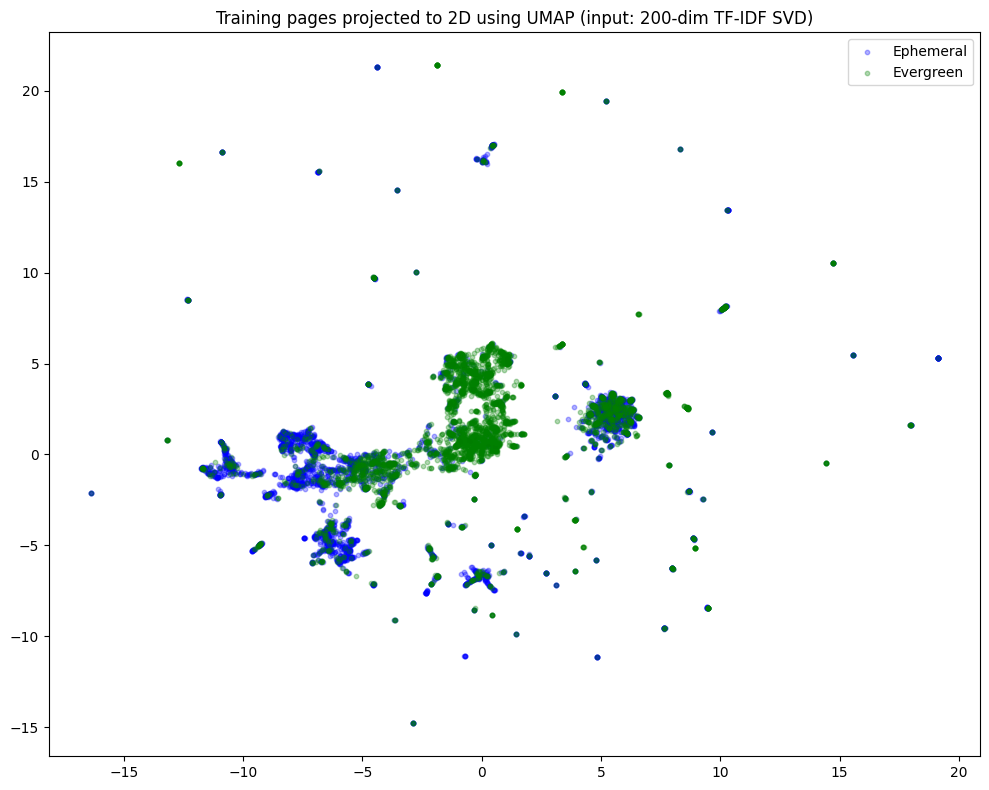

In [37]:
# !pip install umap-learn

#import umap
#import matplotlib.pyplot as plt

reducer = umap.UMAP(n_components=2, n_neighbors=15, random_state=42, n_jobs=-1)
X_train_umap = reducer.fit_transform(X_train_knn)  # using the 200-dim normalized SVD matrix

plt.figure(figsize=(10, 8))
plt.scatter(
    X_train_umap[y == 0, 0], X_train_umap[y == 0, 1],
    c='blue', alpha=0.3, s=10, label='Ephemeral',
)
plt.scatter(
    X_train_umap[y == 1, 0], X_train_umap[y == 1, 1],
    c='green', alpha=0.3, s=10, label='Evergreen',
)
plt.xlabel('')
plt.ylabel('')
plt.title('Training pages projected to 2D using UMAP (input: 200-dim TF-IDF SVD)')
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
# Generate out-of-fold predictions for each base model
# Each base model predicts on data it didn't train on (using cross-validation).
# These predictions become the meta-learner's training input.

from sklearn.model_selection import cross_val_predict

# Logistic Regression: input = TF-IDF + structured features
oof_logistic_regression = cross_val_predict(
    LogisticRegression(C=1.0, solver='liblinear', max_iter=1000),
    X_train_lr, y, cv=cv, method='predict_proba', n_jobs=-1,
)[:, 1]  # take probability of class 1 (evergreen)

# Classification Tree: input = structured features only
oof_classification_tree = cross_val_predict(
    DecisionTreeClassifier(max_depth=8, min_samples_leaf=20, random_state=42),
    X_train_tree, y, cv=cv, method='predict_proba', n_jobs=-1,
)[:, 1]

# K-Nearest Neighbors: input = SVD-reduced TF-IDF
oof_knn = cross_val_predict(
    KNeighborsClassifier(n_neighbors=25, weights='distance', metric='cosine', n_jobs=-1),
    X_train_knn, y, cv=cv, method='predict_proba', n_jobs=-1,
)[:, 1]

# Stack the three prediction columns into a single matrix for the meta-learner
stacker_input_train = pd.DataFrame({
    'logistic_regression': oof_logistic_regression,
    'classification_tree': oof_classification_tree,
    'knn': oof_knn,
})

print(f"Stacker input shape: {stacker_input_train.shape}")
print(f"\nFirst 5 rows of out-of-fold predictions:")
print(stacker_input_train.head().round(3))
print(f"\nCorrelation between base model predictions:")
print(stacker_input_train.corr().round(3))

#see some disagreement even in first 5 rows - which justifies stacking

Stacker input shape: (7395, 3)

First 5 rows of out-of-fold predictions:
   logistic_regression  classification_tree    knn
0                0.036                0.167  0.293
1                0.219                0.101  0.169
2                0.612                0.279  0.825
3                0.487                0.862  0.492
4                0.118                0.143  0.083

Correlation between base model predictions:
                     logistic_regression  classification_tree    knn
logistic_regression                1.000                0.855  0.907
classification_tree                0.855                1.000  0.797
knn                                0.907                0.797  1.000


In [41]:
# Train the meta-learner (Logistic Regression) on out-of-fold predictions
# Cross-validate to get an honest stacker AUC

meta_learner = LogisticRegression(C=1.0, solver='liblinear', max_iter=1000)

scores_stacker = cross_val_score(
    meta_learner, stacker_input_train, y,
    cv=cv, scoring='roc_auc', n_jobs=-1,
)
print(f"EnsembleModel AUC per fold: {scores_stacker.round(4)}")
print(f"EnsembleModel mean AUC: {scores_stacker.mean():.4f}  ± {scores_stacker.std():.4f}")

# Compare to base models
print("\n--- Comparison ---")
print(f"Logistic Regression: 0.8643")
print(f"Classification Tree: 0.8213")
print(f"K-Nearest Neighbors: 0.8611")
print(f"EnsembleModel:             {scores_stacker.mean():.4f}")

#Ensemble model performed better than each individual with lower stnadard deviation

EnsembleModel AUC per fold: [0.8645 0.8821 0.8708 0.8654 0.8758]
EnsembleModel mean AUC: 0.8717  ± 0.0066

--- Comparison ---
Logistic Regression: 0.8643
Classification Tree: 0.8213
K-Nearest Neighbors: 0.8611
EnsembleModel:             0.8717


In [42]:
#Inspect ensemble weights — which base model does it trust most?
meta_learner.fit(stacker_input_train, y)

print("Ensemble coefficients (higher = more trusted base model):")
for name, coef in zip(stacker_input_train.columns, meta_learner.coef_[0]):
    print(f"  {name:25s}  {coef:+.3f}")
print(f"  intercept                 {meta_learner.intercept_[0]:+.3f}")

Ensemble coefficients (higher = more trusted base model):
  logistic_regression        +2.944
  classification_tree        +0.482
  knn                        +2.314
  intercept                 -2.796


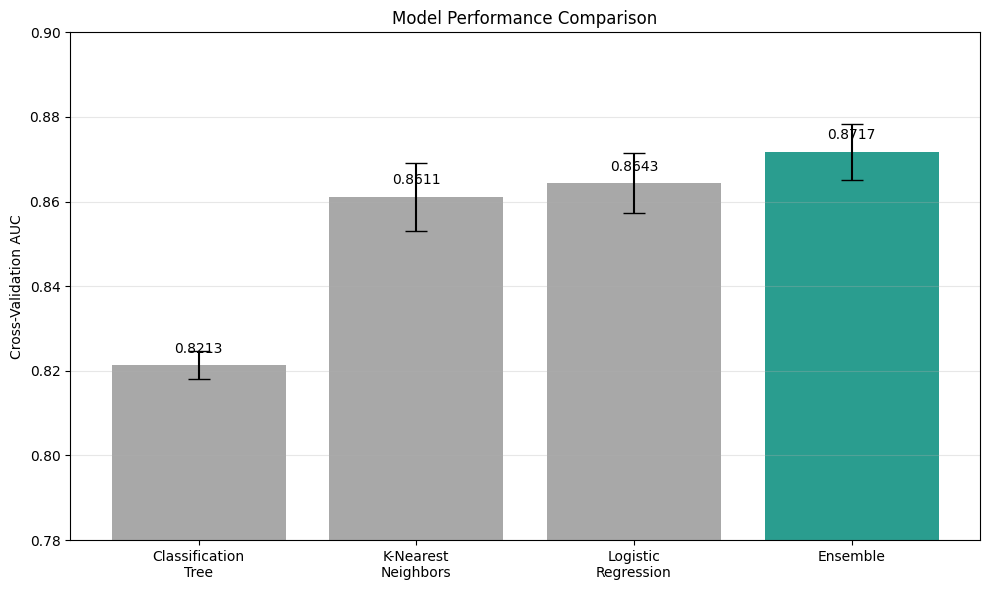

In [43]:
# Bar chart comparing AUC across all models
import matplotlib.pyplot as plt

model_names = ['Classification\nTree', 'K-Nearest\nNeighbors', 'Logistic\nRegression', 'Ensemble']
auc_means = [0.8213, 0.8611, 0.8643, scores_stacker.mean()]
auc_stds  = [0.0033, 0.0080, 0.0071, scores_stacker.std()]

colors = ['#a8a8a8', '#a8a8a8', '#a8a8a8', '#2a9d8f']  # ensemble in green, others gray

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, auc_means, yerr=auc_stds, color=colors, capsize=8)
plt.ylabel('Cross-Validation AUC')
plt.title('Model Performance Comparison')
plt.ylim(0.78, 0.90)
plt.grid(axis='y', alpha=0.3)

# Annotate each bar with its AUC value
for bar, auc in zip(bars, auc_means):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{auc:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

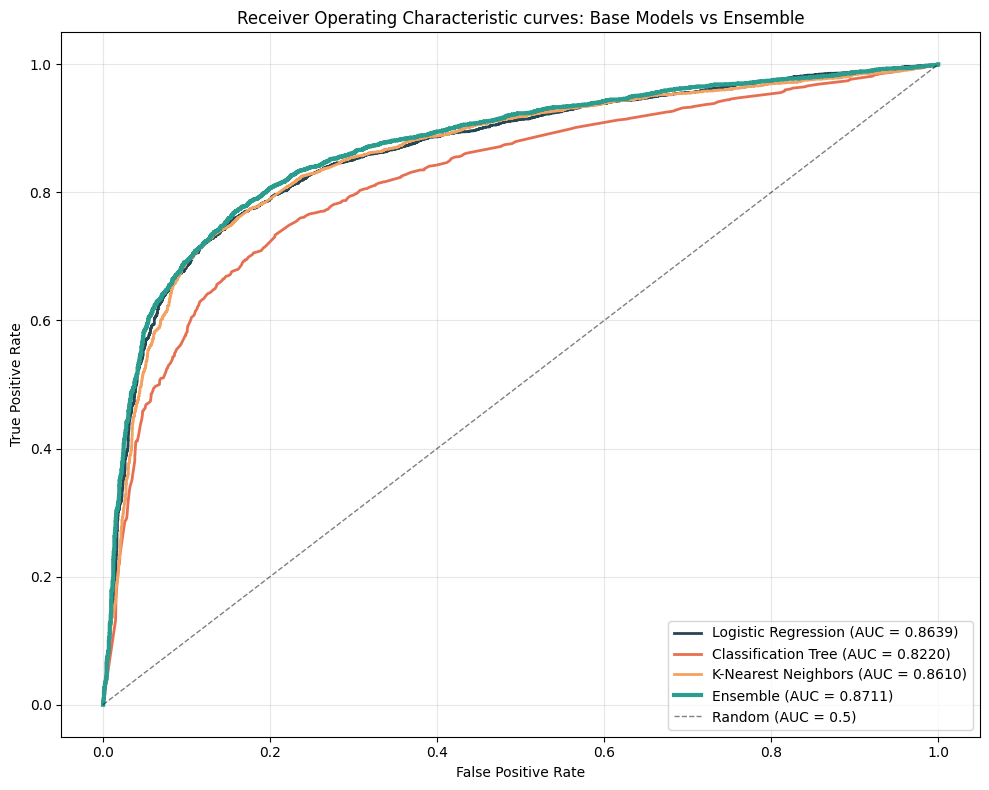

In [45]:
# ROC curves for all four models
from sklearn.metrics import roc_curve, auc as auc_score

plt.figure(figsize=(10, 8))

models_predictions = {
    'Logistic Regression':  (oof_logistic_regression, '#264653'),
    'Classification Tree':  (oof_classification_tree, '#e76f51'),
    'K-Nearest Neighbors':  (oof_knn,                  '#f4a261'),
}

# Plot each base model's ROC curve
for name, (predictions, color) in models_predictions.items():
    fpr, tpr, _ = roc_curve(y, predictions)
    auc_value = auc_score(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc_value:.4f})')

# Plot the ensemble's ROC curve (use cross_val_predict to get out-of-fold ensemble predictions)
oof_ensemble = cross_val_predict(
    LogisticRegression(C=1.0, solver='liblinear', max_iter=1000),
    stacker_input_train, y, cv=cv, method='predict_proba', n_jobs=-1,
)[:, 1]
fpr, tpr, _ = roc_curve(y, oof_ensemble)
auc_value = auc_score(fpr, tpr)
plt.plot(fpr, tpr, color='#2a9d8f', lw=3, label=f'Ensemble (AUC = {auc_value:.4f})')

# Diagonal reference (random classifier)
plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic curves: Base Models vs Ensemble')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
# Generate test predictions from the ensemble
# Refit each base model on the FULL training data, then predict on test

# Logistic Regression
logistic_regression_final = LogisticRegression(C=1.0, solver='liblinear', max_iter=1000)
logistic_regression_final.fit(X_train_lr, y)
test_pred_logistic_regression = logistic_regression_final.predict_proba(X_test_lr)[:, 1]

# Classification Tree
classification_tree_final = DecisionTreeClassifier(max_depth=8, min_samples_leaf=20, random_state=42)
classification_tree_final.fit(X_train_tree, y)
test_pred_classification_tree = classification_tree_final.predict_proba(X_test_tree)[:, 1]

# K-Nearest Neighbors
knn_final = KNeighborsClassifier(n_neighbors=25, weights='distance', metric='cosine', n_jobs=-1)
knn_final.fit(X_train_knn, y)
test_pred_knn = knn_final.predict_proba(X_test_knn)[:, 1]

# Build the test-side input for the meta-learner: same 3-column structure as training
stacker_input_test = pd.DataFrame({
    'logistic_regression': test_pred_logistic_regression,
    'classification_tree': test_pred_classification_tree,
    'knn': test_pred_knn,
})

# Predict with the already-fitted ensemble
test_pred_ensemble = meta_learner.predict_proba(stacker_input_test)[:, 1]

print(f"Test predictions ready. Shape: {test_pred_ensemble.shape}")
print(f"Range: {test_pred_ensemble.min():.4f} to {test_pred_ensemble.max():.4f}")
print(f"Mean: {test_pred_ensemble.mean():.4f}")

Test predictions ready. Shape: (3171,)
Range: 0.0659 to 0.9499
Mean: 0.4983


In [48]:
# Generating submission file
# Kaggle's StumbleUpon competition expects: urlid, label
# where label is the predicted probability of evergreen (between 0 and 1)

submission = pd.DataFrame({
    'urlid': test['urlid'],
    'label': test_pred_ensemble,
})

submission.to_csv('submission.csv', index=False)
print(f"Submission file written: submission.csv")
print(f"Shape: {submission.shape}")
print(f"\nFirst 5 rows:")
print(submission.head())

Submission file written: submission.csv
Shape: (3171, 2)

First 5 rows:
   urlid     label
0   5865  0.912598
1    782  0.124317
2   6962  0.552489
3   7640  0.129469
4   3589  0.572242
